### 01. Imports et chargement des modèles

In [1]:
import pandas as pd
import numpy as np
import joblib

# --- chemins vers les modèles ---
path_dpe_sans = r"C:\Users\km_sa\DEV\m2_enedis_dpe_app\models\DPE-Sans Conso\rf_dpe_predictif.joblib"
path_dpe_avec = r"C:\Users\km_sa\DEV\m2_enedis_dpe_app\models\DPE-Avec Conso\rf_dpe_conso_predictif.joblib"
path_conso = r"C:\Users\km_sa\DEV\m2_enedis_dpe_app\models\Conso\rf_conso_final.joblib"

rf_dpe_sans = joblib.load(path_dpe_sans)
rf_dpe_avec = joblib.load(path_dpe_avec)
rf_conso = joblib.load(path_conso)

print("Modèles chargés avec succès :")
print(" - DPE sans conso")
print(" - DPE avec conso")
print(" - Modèle conso")

Modèles chargés avec succès :
 - DPE sans conso
 - DPE avec conso
 - Modèle conso


### 02. Fiche technique des 3 modèles

In [16]:
import pandas as pd

def fiche_modele(nom, model):
    """Retourne une fiche synthétique du modèle sklearn Pipeline"""
    clf = model.named_steps[list(model.named_steps.keys())[-1]]  # dernière étape (le modèle)
    preprocessor = model.named_steps["preprocessor"]

    infos = {
        "Nom du modèle": nom,
        "Type de modèle": type(clf).__name__,
        "Nb total de features": len(preprocessor.get_feature_names_out()),
        "Nb features numériques": len(preprocessor.transformers_[0][2]),
        "Nb features catégorielles": len(preprocessor.transformers_[1][2]),
        "Profondeur max": clf.get_params().get("max_depth", None),
        "Nb arbres (si forêt)": clf.get_params().get("n_estimators", None),
        "max_features": clf.get_params().get("max_features", None),
        "min_samples_split": clf.get_params().get("min_samples_split", None),
        "min_samples_leaf": clf.get_params().get("min_samples_leaf", None),
        "Random state": clf.get_params().get("random_state", None),
    }
    return infos


# Générer les fiches pour les 3 modèles
fiches = [
    fiche_modele("DPE sans conso", rf_dpe_sans),
    fiche_modele("DPE avec conso", rf_dpe_avec),
    fiche_modele("Consommation (régression)", rf_conso),
]

df_fiches = pd.DataFrame(fiches)

# Affichage clair
print("Fiches techniques des modèles :")
display(df_fiches.style.background_gradient(cmap="Blues").set_caption("Comparatif des 3 modèles"))


Fiches techniques des modèles :


,Nom du modèle,Type de modèle,Nb total de features,Nb features numériques,Nb features catégorielles,Profondeur max,Nb arbres (si forêt),max_features,min_samples_split,min_samples_leaf,Random state
0,DPE sans conso,RandomForestClassifier,39,6,6,nan,300,sqrt,2,1,42
1,DPE avec conso,RandomForestClassifier,40,7,6,25.000000,300,sqrt,5,1,42
2,Consommation (régression),RandomForestRegressor,39,6,6,25.000000,400,sqrt,5,1,42


### 03. Charger 1000 logements de validation

In [22]:
# Charger ton dataset complet
path = "../data/Prepared/prepared_dpe_regroupe_final.csv"
df = pd.read_csv(path)

# Colonnes nécessaires (mêmes que dans les modèles)
features_common = [
    "volume_logement", "hauteur_sous_plafond", "nombre_niveau_logement", "anciennete",
    "isolation_toiture", "score_isolation_moyen",
    "qualite_isolation_murs", "qualite_isolation_menuiseries",
    "type_energie_principale_chauffage", "energie_regroupee",
    "type_logement_source", "classe_annee_construction",
    "conso_m2", "etiquette_dpe_regroupee"
]

# Garder uniquement les lignes complètes
df_sample = df[features_common].dropna().sample(1000, random_state=213).reset_index(drop=True)

print("échantillon de test chargé :")
display(df_sample.head(10))


échantillon de test chargé :


,volume_logement,hauteur_sous_plafond,nombre_niveau_logement,anciennete,isolation_toiture,score_isolation_moyen,qualite_isolation_murs,qualite_isolation_menuiseries,type_energie_principale_chauffage,energie_regroupee,type_logement_source,classe_annee_construction,conso_m2,etiquette_dpe_regroupee
0,252.20,2.6,1.0,59.0,0.0,3.0,INSUFFISANTE,BONNE,GAZ NATUREL,gaz,EXISTANT,1949_1974,280.931959,E
1,217.75,2.5,1.0,31.0,0.0,2.0,INSUFFISANTE,MOYENNE,ÉLECTRICITÉ,electrique,EXISTANT,1990_1999,247.050517,D
2,197.75,2.5,1.0,45.0,1.0,3.0,BONNE,TRÈS BONNE,GAZ NATUREL,gaz,EXISTANT,1975_1989,144.864728,C
3,145.00,2.5,1.0,68.0,0.0,3.0,INSUFFISANTE,BONNE,RÉSEAU DE CHAUFFAGE URBAIN,autre,EXISTANT,1949_1974,222.729310,D
4,85.75,2.5,1.0,45.0,1.0,2.0,INSUFFISANTE,MOYENNE,RÉSEAU DE CHAUFFAGE URBAIN,autre,EXISTANT,1975_1989,293.583090,E
5,71.50,2.5,1.0,45.0,1.0,2.0,MOYENNE,MOYENNE,ÉLECTRICITÉ,electrique,EXISTANT,1975_1989,325.209790,E
6,151.00,2.5,1.0,0.0,0.0,3.0,BONNE,TRÈS BONNE,GAZ NATUREL,gaz,NEUF,apres_2012,88.352649,C
7,168.75,2.5,1.0,0.0,0.0,3.0,BONNE,TRÈS BONNE,RÉSEAU DE CHAUFFAGE URBAIN,autre,NEUF,apres_2012,102.927407,A_B
8,241.44,2.4,1.0,30.0,0.0,2.0,MOYENNE,TRÈS BONNE,GAZ NATUREL,gaz,EXISTANT,1990_1999,82.455268,C
9,117.50,2.5,1.0,26.0,0.0,2.5,MOYENNE,BONNE,GAZ NATUREL,gaz,EXISTANT,1990_1999,114.008511,C


### 04. Prédictions pour les 3 scénarios

In [23]:
results = []

for i, row in df_sample.iterrows():
    logement = pd.DataFrame([row.drop("etiquette_dpe_regroupee")])

    # ① DPE sans conso
    logement_sans_conso = logement.drop(columns=["conso_m2"])
    y_pred_sans = rf_dpe_sans.predict(logement_sans_conso)[0]

    # ② DPE avec conso renseignée
    y_pred_avec = rf_dpe_avec.predict(logement)[0]

    # ③ DPE avec conso prédite
    logement_for_conso = logement_sans_conso.copy()
    conso_pred_log = rf_conso.predict(logement_for_conso)
    conso_pred = np.expm1(conso_pred_log)
    logement_for_conso["conso_m2"] = conso_pred
    y_pred_chaine = rf_dpe_avec.predict(logement_for_conso)[0]

    results.append({
        "Réel DPE": row["etiquette_dpe_regroupee"],
        "Conso réelle": round(row["conso_m2"], 1),
        "Conso prédite": round(conso_pred[0], 1),
        "DPE sans conso": y_pred_sans,
        "DPE avec conso (renseignée)": y_pred_avec,
        "DPE via conso prédite": y_pred_chaine
    })

df_results = pd.DataFrame(results)
display(df_results.head(10))


,Réel DPE,Conso réelle,Conso prédite,DPE sans conso,DPE avec conso (renseignée),DPE via conso prédite
0,E,280.9,227.9,E,E,D
1,D,247.1,225.4,D,D,D
2,C,144.9,122.1,C,C,C
3,D,222.7,219.3,D,D,D
4,E,293.6,246.4,E,E,D
5,E,325.2,287.7,E,E,E
6,C,88.4,80.4,C,C,C
7,A_B,102.9,78.5,A_B,A_B,C
8,C,82.5,85.2,C,C,C
9,C,114.0,121.1,C,C,C


### 05. Évaluation et comparaison globale

In [24]:
from sklearn.metrics import accuracy_score

acc_sans = accuracy_score(df_results["Réel DPE"], df_results["DPE sans conso"])
acc_avec = accuracy_score(df_results["Réel DPE"], df_results["DPE avec conso (renseignée)"])
acc_chaine = accuracy_score(df_results["Réel DPE"], df_results["DPE via conso prédite"])

print("Résultats d'accuracy pour les 3 scénarios sur 1000 logements :")
print(f"Accuracy DPE sans conso         : {acc_sans:.3f}")
print(f"Accuracy DPE avec conso         : {acc_avec:.3f}")
print(f"Accuracy DPE via conso prédite  : {acc_chaine:.3f}")


Résultats d'accuracy pour les 3 scénarios sur 1000 logements :
Accuracy DPE sans conso         : 0.845
Accuracy DPE avec conso         : 0.980
Accuracy DPE via conso prédite  : 0.706


### 06. Barplot comparatif

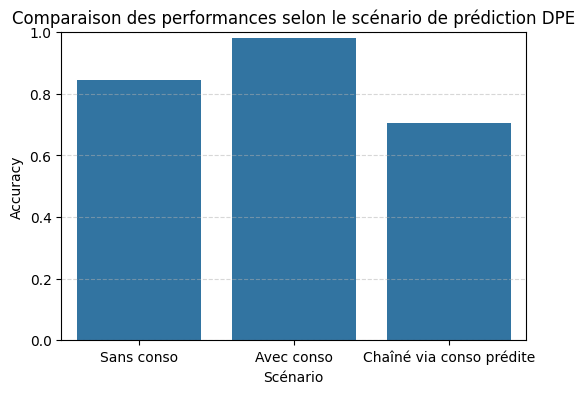

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

acc_df = pd.DataFrame({
    "Scénario": ["Sans conso", "Avec conso", "Chaîné via conso prédite"],
    "Accuracy": [acc_sans, acc_avec, acc_chaine]
})

plt.figure(figsize=(6,4))
sns.barplot(x="Scénario", y="Accuracy", data=acc_df)
plt.title("Comparaison des performances selon le scénario de prédiction DPE")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()
